# Task 1: Data Cleaning & Exploratory Data Analysis (EDA)
### House Prices Dataset

**Goal:** Clean the raw House Prices dataset, handle missing values, encode categorical features, remove outliers, and explore relationships between features and `SalePrice` before modeling.

**Dataset:** Kaggle - House Prices: Advanced Regression Techniques (`train.csv`)

## Step 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

## Step 2: Load the Dataset

In [2]:
df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.shape

(1460, 81)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## Step 3: Exploratory Data Analysis (EDA)
Understanding the target variable (`SalePrice`) and its relationship with other features.

### 3.1 SalePrice Distribution

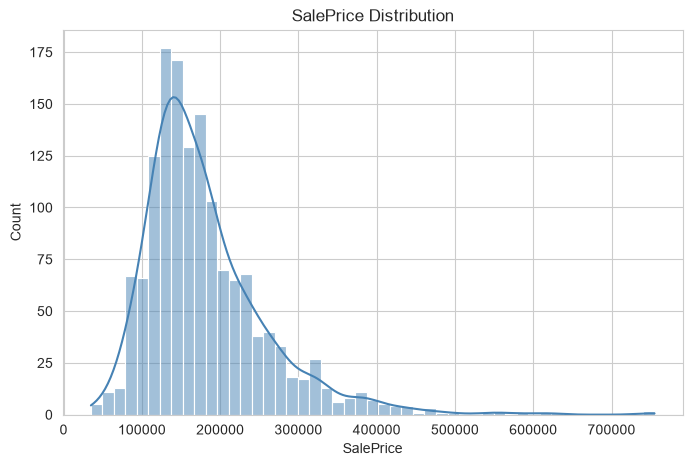

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True, color='steelblue')
plt.title("SalePrice Distribution")
plt.savefig("1_saleprice_distribution.png")
plt.show()

### 3.2 Correlation Heatmap
Check which numeric features correlate most with SalePrice and with each other.

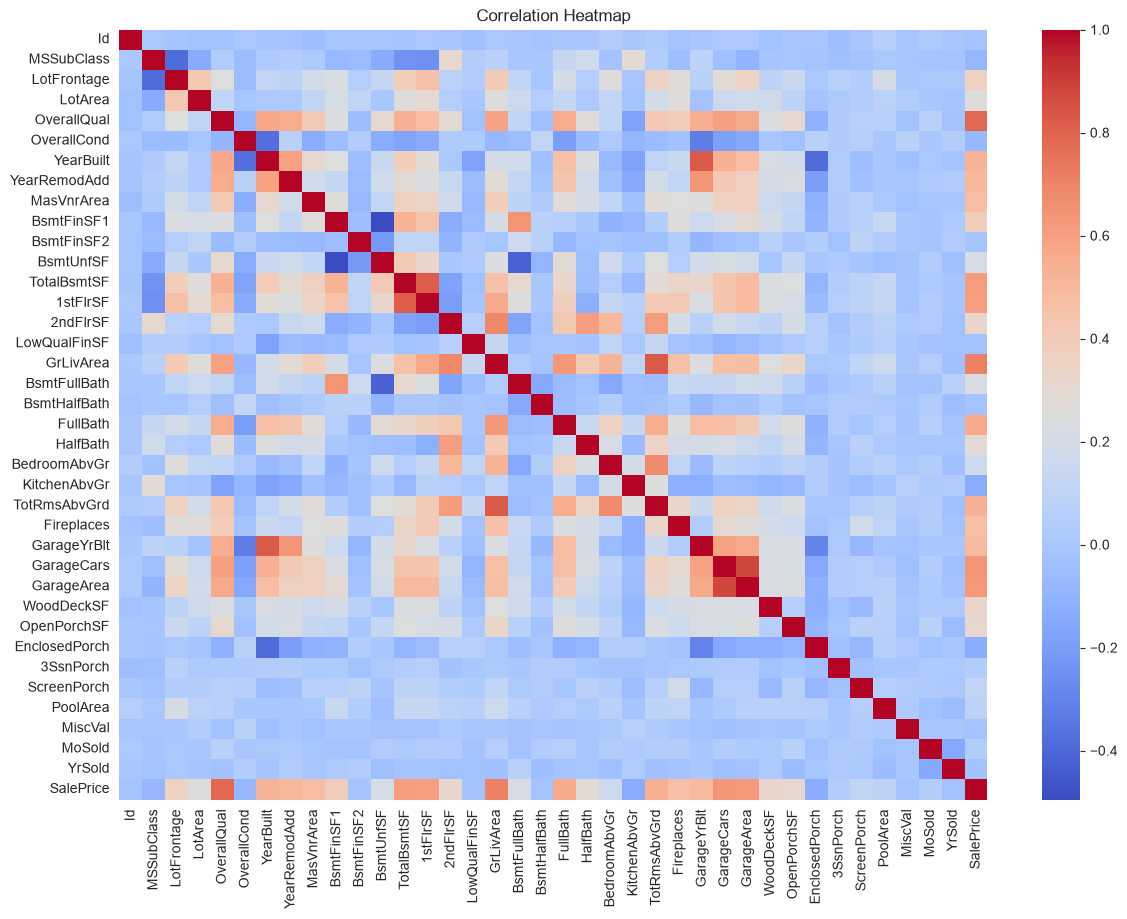

In [6]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("3_correlation_heatmap.png")
plt.show()

### 3.3 Living Area vs Sale Price

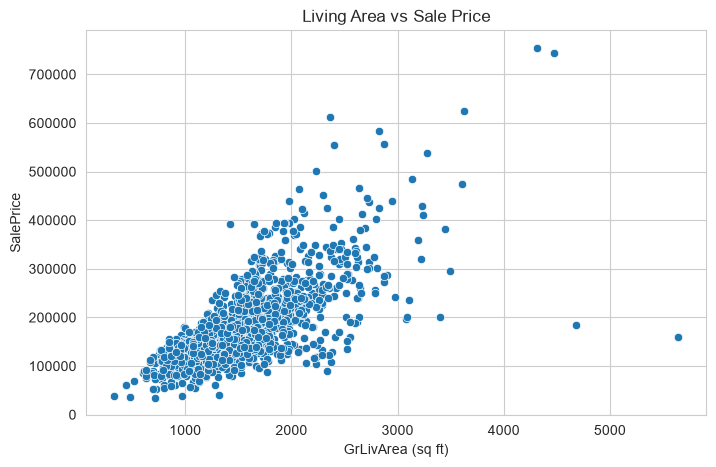

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.title("Living Area vs Sale Price")
plt.xlabel("GrLivArea (sq ft)")
plt.ylabel("SalePrice")
plt.savefig("4_grlivarea_vs_saleprice.png")
plt.show()

### 3.4 SalePrice Outliers

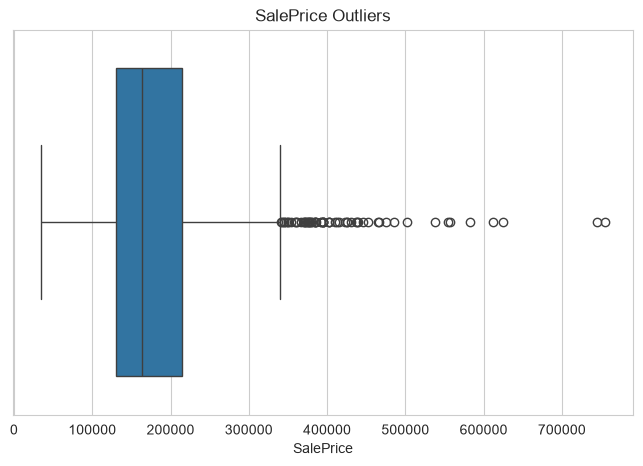

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['SalePrice'])
plt.title("SalePrice Outliers")
plt.savefig("5_saleprice_outliers.png")
plt.show()

### 3.5 Overall Quality vs Sale Price

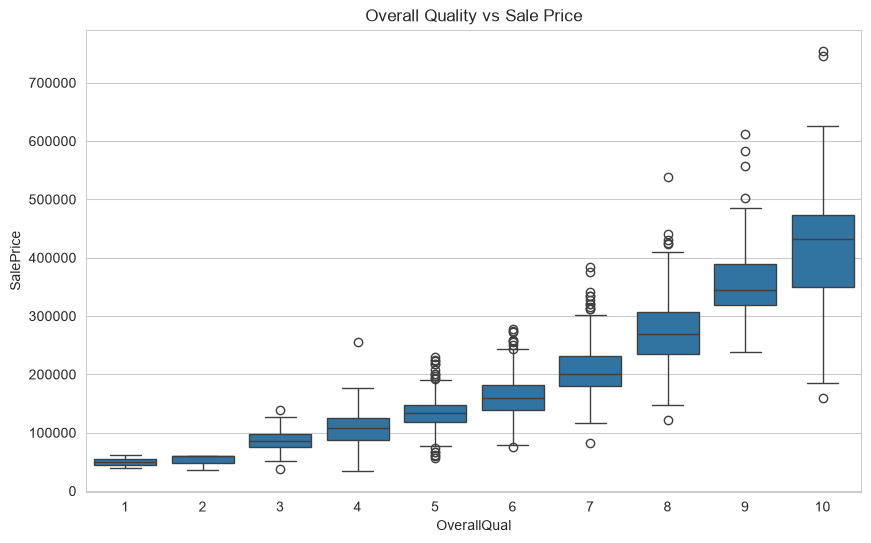

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['OverallQual'], y=df['SalePrice'])
plt.title("Overall Quality vs Sale Price")
plt.savefig("6_overallqual_vs_saleprice.png")
plt.show()

### 3.6 Missing Values Overview

In [10]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


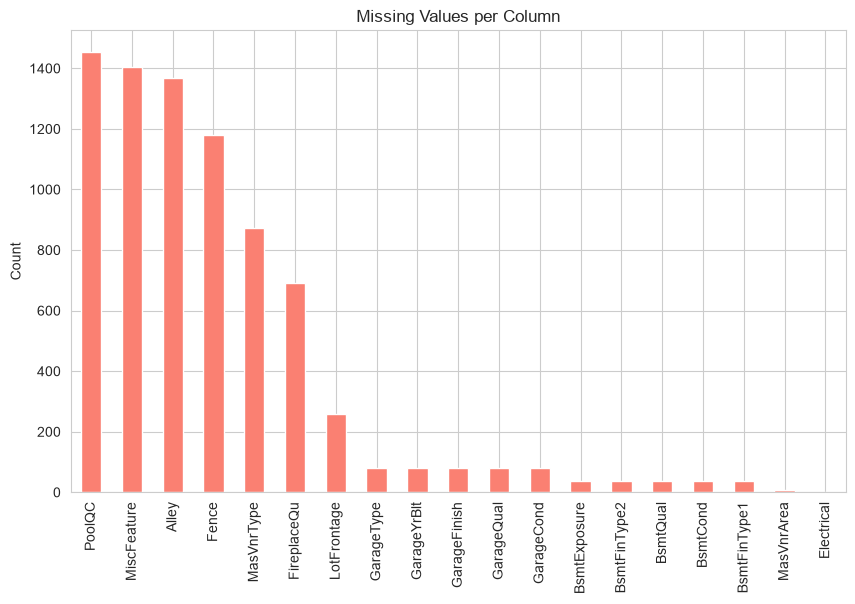

In [11]:
plt.figure(figsize=(10,6))
missing.plot(kind='bar', color='salmon')
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.savefig("2_missing_values.png")
plt.show()

## Step 4: Data Cleaning
Handle missing values based on their meaning:
- Some `NaN`s mean **"feature not present"** (e.g. no pool, no alley) → fill with `'None'`
- Some `NaN`s in numeric columns mean **zero** (e.g. no garage → GarageYrBlt = 0)
- `LotFrontage` is filled using the **median per neighborhood** (more accurate than a global median)
- `Electrical` (only 1 missing value) is filled with the **mode**

### 4.1 Fill 'None' for features that don't exist

In [12]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

for col in none_cols:
    df[col] = df[col].fillna('None')

### 4.2 Fill 0 for numeric features where NaN means 'none'

In [13]:
zero_cols = ['GarageYrBlt', 'MasVnrArea']

for col in zero_cols:
    df[col] = df[col].fillna(0)

### 4.3 Fill LotFrontage using neighborhood median

In [14]:
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

### 4.4 Fill Electrical with mode (most frequent value)

In [15]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

### 4.5 Verify No Missing Values Remain

In [16]:
df.isnull().sum().sum()

np.int64(0)

## Step 5: Encode Categorical (Quality) Features
Quality-related columns are ordinal (e.g. Excellent > Good > Average), so we Label Encode them.

In [17]:
from sklearn.preprocessing import LabelEncoder

quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                 'HeatingQC', 'KitchenQual', 'FireplaceQu',
                 'GarageQual', 'GarageCond', 'PoolQC']

le = LabelEncoder()
for col in quality_cols:
    df[col] = le.fit_transform(df[col])

In [18]:
# Remaining non-numeric (categorical) columns
df.select_dtypes(include='object').columns

C:\Users\ULC\AppData\Local\Temp\ipykernel_4220\4049365335.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical',
       'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence',
       'MiscFeature', 'SaleType', 'SaleCondition'],
      dtype='str')

## Step 6: Outlier Removal
Remove extreme outliers in `GrLivArea` (very large houses with unusually low prices — known issue in this dataset).

In [19]:
print("Shape before removing outliers:", df.shape)
df = df[df['GrLivArea'] < 4500]
print("Shape after removing outliers:", df.shape)

Shape before removing outliers: (1460, 81)
Shape after removing outliers: (1458, 81)


## Step 7: Final Sanity Check

In [20]:
print("Missing values:", df.isnull().sum().sum())
print("Non-numeric columns:", df.select_dtypes(include='object').columns.tolist())
print("Final shape:", df.shape)

Missing values: 0
Non-numeric columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Final shape: (1458, 81)


C:\Users\ULC\AppData\Local\Temp\ipykernel_4220\173166795.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Non-numeric columns:", df.select_dtypes(include='object').columns.tolist())


## Step 8: Feature Scaling
Scale key numeric features so they're on a comparable range (useful for distance-based models later).

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = ['GrLivArea', 'LotArea', 'TotalBsmtSF', '1stFlrSF']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

## Step 9: Save Cleaned Dataset

In [22]:
df.to_csv("cleaned_house_prices.csv", index=False)
print("File saved successfully!")

File saved successfully!
